In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from itertools import product

import sys

from pathlib import Path
nb_dir = Path.cwd()
help_func_path = os.path.join(nb_dir,'helper_code')

sys.path.append(help_func_path) 

from plotting_functions import scatter_helper, plot_3d_scatters
from saving_functions import save_dataset,delete_dataset
from lmm_helper_funcs import latent_metric_model_gp

In [2]:
from scipy import stats
from sklearn.metrics.pairwise import rbf_kernel

In [3]:
DATA_ROOT = Path(os.environ["EPHEMERAL"]) / "pyspoc_synthetic_data"
DATA_ROOT.mkdir(parents=True, exist_ok=True)

sampling angles uniformly right now, doesnt lead to area uniform sampling because of the distortion of distances 

(eg think of sampling from a cylinders surface vs surface of torus)

area uniform sampling on manifolds from their parametrizations is nontrivial, might need rejection sampling or some stuff. there's an R package for area uniform sampling of manifolds, here: https://github.com/tdaverse/tdaunif/tree/main

for future: use the samplers from https://cran.r-project.org/web/packages/tdaunif/vignettes/tdaunif.html (it's in R so would need to be reimplemented in python)

In [4]:
def torus_sampler(n, random_state, R=3.0, r=0.5,angle_scale=2.0,angle_phase_diff=0):
    """
    sample n points on a torus of major radius R (distance from the center of the tube to the center of the torus)
    and minor radius r (radius of tube)
    angle_scale and angle_phase_diff are scaling PI
    return array of shape (n, 3)
    """
    rng = np.random.default_rng(seed=random_state)

    # sample theta,phi
    # angle-uniform sampling    
    theta = angle_scale * np.pi * rng.random(size=n) + angle_phase_diff * np.pi
    phi = angle_scale * np.pi * rng.random(size=n) + angle_phase_diff * np.pi
    
    # area uniform sampling??
    # area of torus - integral r*(R + r*sin(theta)) d(theta) d(phi)
    # total area 4 * pi^2 r * R
    # r*(R + r*sin(theta))    
    
    # polar coords
    # ref wiki, https://en.wikipedia.org/wiki/Torus#Geometry
    x = (R + r * np.cos(phi)) * np.cos(theta)
    y = (R + r * np.cos(phi)) * np.sin(theta)
    z = r * np.sin(phi)
    return np.stack([x, y, z], axis=1)

## initial plotting and exploration

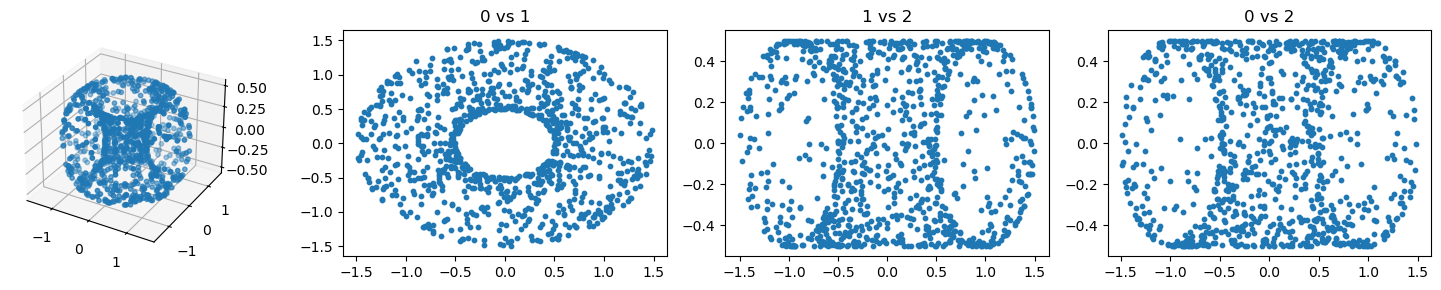

In [5]:
seed= 0
n_samples = 1000
n_features = 200
noise_param = 0.5
torus_params = {'R' : 1, 'r' : 0.5}
len_scale_param = 1

rng_lmm = np.random.default_rng(seed=seed)
seeds_lmm = rng_lmm.integers(0, 2**20, size=3).tolist()    

random_states = {'latent' : seeds_lmm[0], 'gp' : seeds_lmm[1], 'noise' :seeds_lmm[2]}

Z = torus_sampler(n_samples, random_state = random_states['latent'], R=torus_params['R'], r=torus_params['r'],angle_scale=2)
plot_3d_scatters(Z,'')

In [6]:
X = latent_metric_model_gp(n_samples, n_features, Z, 0.1, random_states, length_scale=len_scale_param)

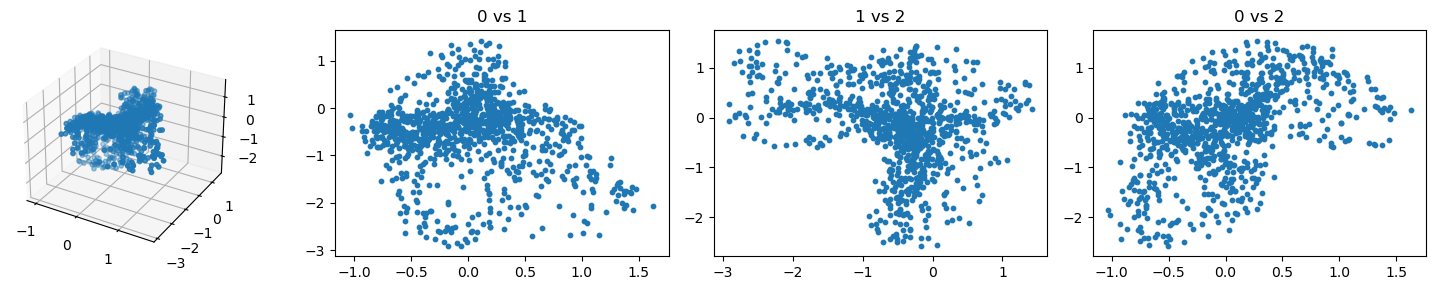

In [7]:
plot_3d_scatters(X,'')

In [8]:
# can increase/decrease density or have partial sampling by varying the angle_scale and angle_phase_diff parameters when sampling theta and phi
# Z1 = torus_sampler(n_samples, random_state = random_states['latent'], R=torus_params['R'], r=torus_params['r'],angle_scale=2,angle_phase_diff=0.5)
# plot_3d_scatters(Z1,'')
# Z2 = torus_sampler(n_samples, random_state = random_states['latent'], R=torus_params['R'], r=torus_params['r'],angle_scale=0.7,angle_phase_diff=0.5)
# plot_3d_scatters(np.vstack([Z1,Z2]),'')

## embedding 3d torus with uniform angle sampling using LMM

future implementaitons could change so that the sampled torus points are shared across different n_feat, but its just x3 features so very lightweight

In [8]:
# delete_dataset('gp_lmm_3dtorus_uniform_angle',DATA_ROOT)

In [10]:
data_gen_name = 'gp_lmm_3dtorus_uniform_angle'
category_lst = ['density']

n_samples_lst = [1000,10000]
n_features_lst = [10,100,1000,10000]
random_seeds_lst = [80,26759]

lmm_noise_param = 0.1 ## for noise added to gp
lmm_len_scale_param = 1 ## for rbf-kernel

# vary torus params, when R < r - self-intersecting
torus_R_lst = [1] 
torus_r_lst = [0.5,2]

torus_angle_scale = 2
torus_angle_phase_diff = 0

for n_samples, n_features in product(n_samples_lst, n_features_lst):
    
    print(n_samples, n_features)

    for torus_R in torus_R_lst:
        
        for torus_r in torus_r_lst:
        
            for sample_num,seed in enumerate(random_seeds_lst):
                
                random_states = {'latent' : seed+8291, 'gp' : seed+213, 'noise' : seed+4837}
                
                Z = torus_sampler(n_samples, random_state = random_states['latent'], R=torus_R, r=torus_r,angle_scale=torus_angle_scale,angle_phase_diff=torus_angle_phase_diff)

                X = latent_metric_model_gp(n_samples, n_features, Z, lmm_noise_param, random_states, length_scale=lmm_len_scale_param)
                
                params_dict = {
                    'torus_R_major' : torus_R,
                    'torus_r_minor' : torus_r,
                    'torus_angle_scale' : torus_angle_scale,
                    'torus_angle_phase_diff' : torus_angle_phase_diff,                    
                    'lmm_noise_param' : lmm_noise_param,
                    'lmm_len_scale_param' : lmm_len_scale_param,
                    'random_states_dict' : random_states
                }
                
                # extra_arr = {
                # }
                                
                try:
                    save_dataset(X, 
                                generator=data_gen_name,
                                params=params_dict,
                                seed=seed,
                                category=category_lst,
                                # extra_arrays=extra_arr, 
                                root=DATA_ROOT)

                except:
                    print('error?')

1000 10


1000 100
1000 1000
1000 10000
10000 10
10000 100
10000 1000
10000 10000


## sample fragmented torus

In [8]:
# currently writing for fragments from same torus, can modify to take R,r as lists for future

def sample_fragmented_torus(n_fragments,n_samples_tot, random_state, R, r,angle_scale_lst,angle_phase_diff_lst,n_samples_lst=None):
    """sample n fragments of a torus"""
    
    if n_samples_lst is not None:
        if len(n_samples_lst)!=n_fragments:
            raise ValueError()
    if len(angle_scale_lst)!=n_fragments:
        raise ValueError()
    if len(angle_phase_diff_lst)!=n_fragments:
        raise ValueError()
    
    ## assume and generate balanced samples
    if n_samples_lst is None:
        n_samples_lst = [n_samples_tot//n_fragments for i in range(n_fragments)]
        n_samples_lst[0] += n_samples_tot - sum(n_samples_lst)        
    
    Z_lst = []    
    for i in range(n_fragments):
        n_samples = n_samples_lst[i]
        torus_angle_scale= angle_scale_lst[i]
        torus_angle_phase_diff = angle_phase_diff_lst[i]
        Z_tmp = torus_sampler(n_samples, random_state = random_state, R=R, r=r,angle_scale=torus_angle_scale,angle_phase_diff=torus_angle_phase_diff)
        Z_lst.append(Z_tmp)
    
    return np.vstack(Z_lst)

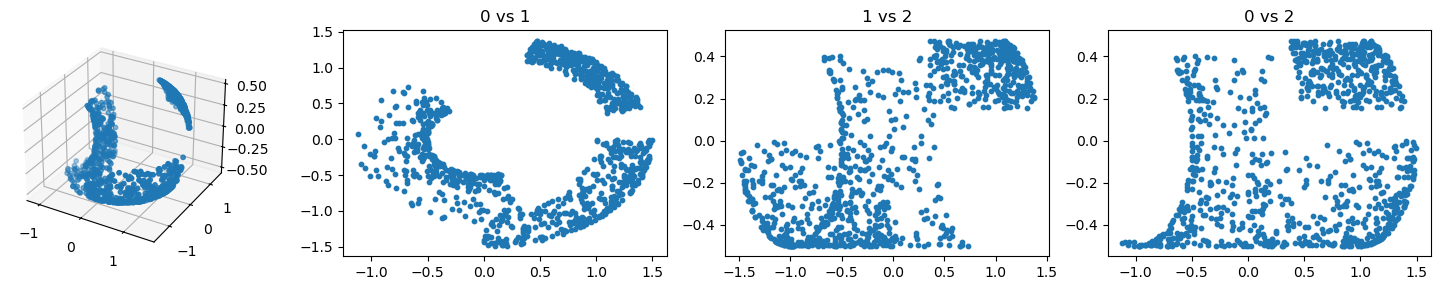

In [9]:
n_torus_frag = 3
torus_angle_scales = [0.3,0.5,0.9]
torus_angle_phase_diffs = [0.1,1.5,0.7]
Z = sample_fragmented_torus(n_torus_frag,1000,0,1,0.5,torus_angle_scales,torus_angle_phase_diffs)
plot_3d_scatters(Z,'')

In [10]:
# plot_3d_scatters(Z,'')

## embedding fragmented torus using LMM

In [11]:
# delete_dataset('gp_lmm_3dtorus_fragmented',DATA_ROOT)

In [12]:
data_gen_name = 'gp_lmm_3dtorus_fragmented'
category_lst = ['density']

n_samples_lst = [1000,10000]
n_features_lst = [10,100,1000]

# had to run the 10k x 10k case separately
# n_samples_lst = [10000]
# n_features_lst = [10000]

random_seeds_lst = [80,26759]

lmm_noise_param = 0.1 ## for noise added to gp
lmm_len_scale_param = 1 ## for rbf-kernel

# vary torus params, when R < r - self-intersecting
torus_R_lst = [1,2] 
torus_r_lst = [0.1,0.5,1,2]

# fix scales for diff fragments @ diff phase
n_torus_frag = 3
torus_angle_scales = [0.3,0.5,0.9]
torus_angle_phase_diffs = [0.1,1.5,0.7]

for n_samples, n_features in product(n_samples_lst, n_features_lst):
    
    print(n_samples, n_features)

    for torus_R in torus_R_lst:
        
        for torus_r in torus_r_lst:
        
            for sample_num,seed in enumerate(random_seeds_lst):
                
                random_states = {'latent' : seed+8291, 'gp' : seed+213, 'noise' : seed+4837}
                
                Z = sample_fragmented_torus(n_torus_frag,n_samples,random_states['latent'],torus_R,torus_r,torus_angle_scales,torus_angle_phase_diffs)

                X = latent_metric_model_gp(n_samples, n_features, Z, lmm_noise_param, random_states, length_scale=lmm_len_scale_param)
                
                params_dict = {
                    'torus_R_major' : torus_R,
                    'torus_r_minor' : torus_r,
                    'n_torus_fragments' : n_torus_frag,
                    'torus_angle_scale' : torus_angle_scales,
                    'torus_angle_phase_diff' : torus_angle_phase_diffs,                    
                    'lmm_noise_param' : lmm_noise_param,
                    'lmm_len_scale_param' : lmm_len_scale_param,
                    'random_states_dict' : random_states
                }
                
                extra_arr = {
                    'fragmented_torus' : Z
                }
                                                
                try:
                    save_dataset(X, 
                                generator=data_gen_name,
                                params=params_dict,
                                seed=seed,
                                category=category_lst,
                                # extra_arrays=extra_arr, 
                                root=DATA_ROOT)
                    del(Z)
                    del(X)

                except:
                    print('error?')

1000 10
1000 100
1000 1000
10000 10
10000 100
10000 1000


(14, 8)


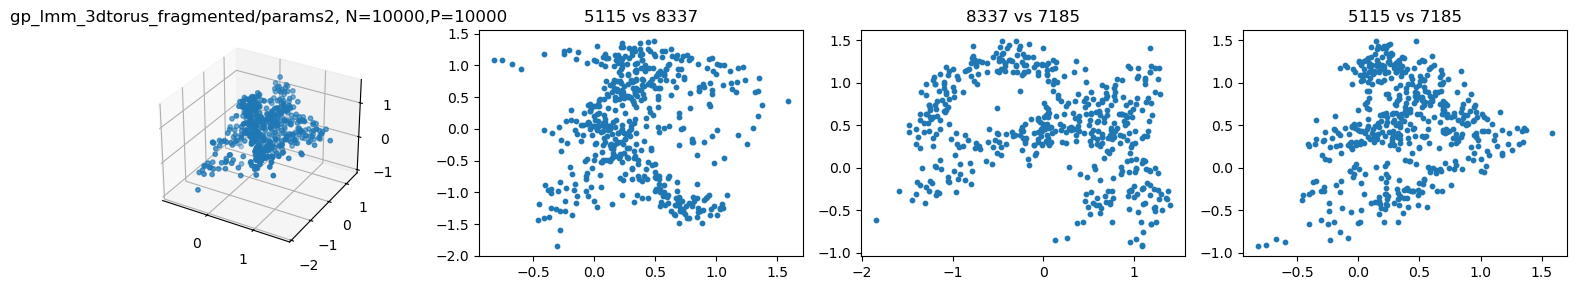

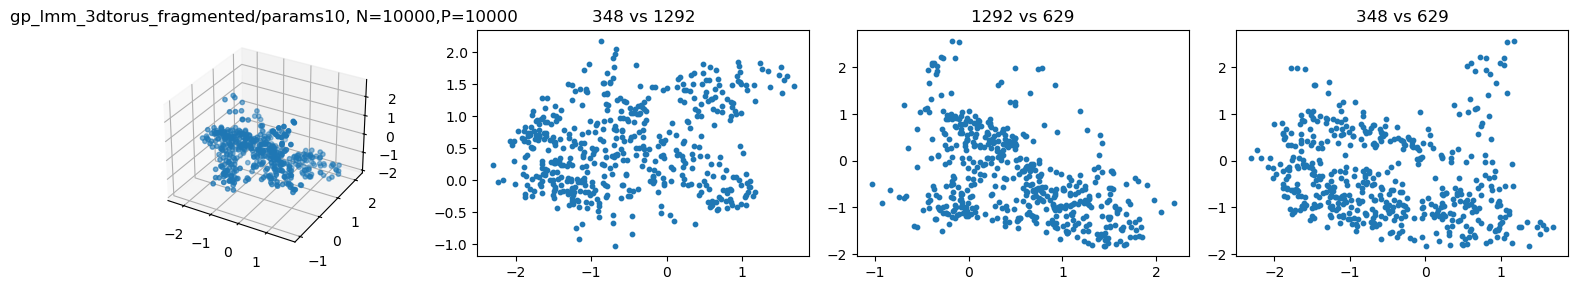

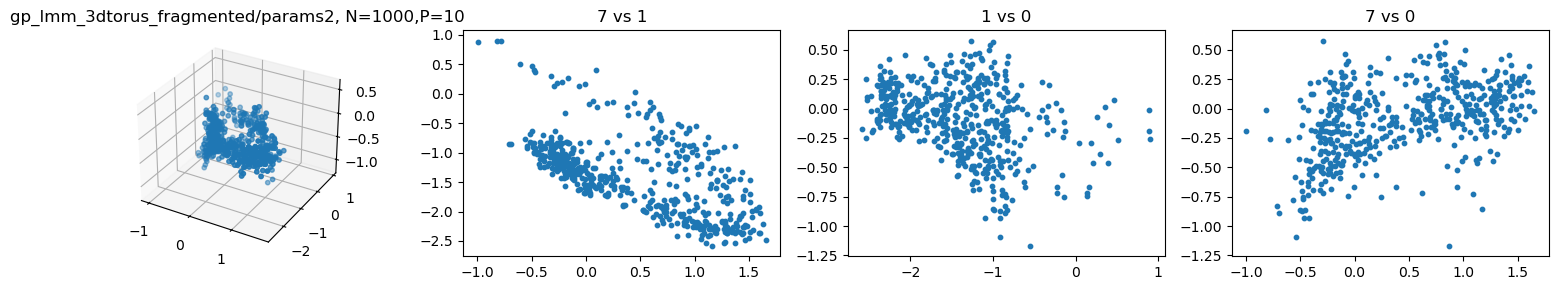

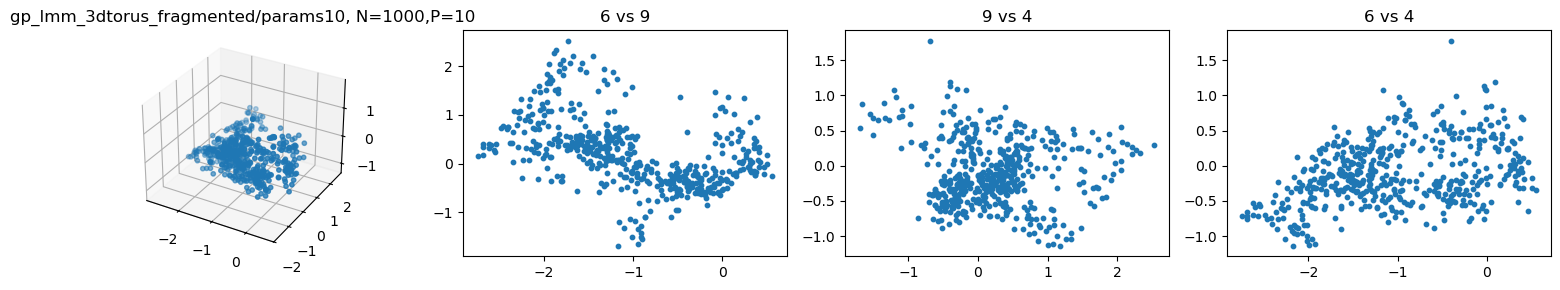

In [13]:
m = pd.read_csv(DATA_ROOT / "manifest.csv")

generator = data_gen_name
params_lst = [f'params{i}' for i in range(0,100) if i%8==2]
m = m[(m.generator == generator) & (m.params_id.isin(params_lst))]
print(m.shape)

max_pts = 500
for r in m.groupby(["generator", "params_id"]).head(2).itertuples():
    X = np.load(DATA_ROOT / f"{r.dataset_id}.npy")
    if len(X) > max_pts:
        rng = np.random.default_rng(0)       
        X = X[rng.choice(len(X), max_pts, replace=False)]
    plot_3d_scatters(X, f"{r.generator}/{r.params_id}, N={r.n_rows},P={r.n_cols}",custom_inx=np.random.choice(r.n_cols, 3, replace=False))

In [19]:
# m = pd.read_csv(DATA_ROOT / "manifest.csv")
# m['generator'].nunique()
# m.groupby(['n_rows','n_cols'])['dataset_id'].count()